# CluMarPareto — Comprehensive Evaluation Notebook

Evaluates feature selection methods across multiple datasets on:
- Accuracy, Runtime, Features Selected, Feature Reduction %
- Stability (multiple runs)
- Convergence (NSGA-II generations)
- Synthetic ground truth (Precision / Recall on informative features)
- Pareto Front analysis

**Methods:**
1. CluMarPareto (full pipeline)
2. NSGA2 Standalone
3. IAMB + NSGA2
4. IAMB Only
5. Random Forest Importance
6. LASSO
7. Baseline (no feature selection)


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

from ucimlrepo import fetch_ucirepo

from Clumarpareto import CluMarPareto
from clustering import DBSCAN_Clustering
from IAMB_1 import IAMB
from NSGA2 import NSGA2_FS

RANDOM_STATE = 42
N_STABILITY_RUNS = 5   # runs for stability analysis
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


## 2. Dataset Loader

In [2]:
def load_datasets():
    datasets = {}

    X, y = make_classification(
        n_samples=1000, n_features=50,
        n_informative=10, n_redundant=20,
        n_repeated=5, n_classes=2,
        random_state=RANDOM_STATE, shuffle=False
    )
    datasets['Synthetic'] = (X, y)
    print("Loaded: Synthetic        ", X.shape)

    try:
        bc   = fetch_ucirepo(id=17)
        X_bc = bc.data.features.values.astype(float)
        y_bc = (bc.data.targets.values.ravel() == 'M').astype(int)
        datasets['BreastCancer'] = (X_bc, y_bc)
        print("Loaded: BreastCancer     ", X_bc.shape)
    except Exception as e:
        print(f"BreastCancer failed: {e}")

    try:
        spectf = fetch_ucirepo(id=96)
        X_sp   = spectf.data.features.values.astype(float)
        y_sp   = (spectf.data.targets.values.ravel().astype(int) > 0).astype(int)
        datasets['SPECTF'] = (X_sp, y_sp)
        print("Loaded: SPECTF           ", X_sp.shape)
    except Exception as e:
        print(f"SPECTF failed: {e}")

    try:
        iono   = fetch_ucirepo(id=52)
        X_io   = iono.data.features.values.astype(float)
        y_io   = (iono.data.targets.values.ravel() == 'g').astype(int)
        col_mask = ~(np.all(np.isnan(X_io), axis=0) | np.all(X_io == 0, axis=0))
        X_io   = X_io[:, col_mask]
        from sklearn.impute import SimpleImputer
        X_io   = SimpleImputer(strategy='median').fit_transform(X_io)
        datasets['Ionosphere'] = (X_io, y_io)
        print("Loaded: Ionosphere       ", X_io.shape)
    except Exception as e:
        print(f"Ionosphere failed: {e}")

    try:
        sonar  = fetch_ucirepo(id=151)
        X_so   = sonar.data.features.values.astype(float)
        y_so   = (sonar.data.targets.values.ravel() == 'M').astype(int)
        datasets['Sonar'] = (X_so, y_so)
        print("Loaded: Sonar            ", X_so.shape)
    except Exception as e:
        print(f"Sonar failed: {e}")

    return datasets

datasets = load_datasets()


Loaded: Synthetic         (1000, 50)
Loaded: BreastCancer      (569, 30)
Loaded: SPECTF            (267, 44)
Loaded: Ionosphere        (351, 33)
Loaded: Sonar             (208, 60)


## 3. Shared Evaluation Helper

In [3]:
def evaluate_on_test(X_train, X_test, y_train, y_test, selected_indices):
    """Fit DecisionTree on selected features, return test accuracy."""
    if len(selected_indices) == 0:
        return 0.0
    clf = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
    clf.fit(X_train[:, selected_indices], y_train)
    return clf.score(X_test[:, selected_indices], y_test)


## 4. Method Runners

In [4]:
# ── Baseline (no feature selection) ─────────────────────────────────────────
def run_baseline(X_train, X_test, y_train, y_test):
    t0  = time.time()
    clf = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    return {
        'runtime':       time.time() - t0,
        'n_selected':    X_train.shape[1],
        'reduction_pct': 0.0,
        'test_acc':      clf.score(X_test, y_test),
        'selected_features': list(range(X_train.shape[1]))
    }

# ── CluMarPareto ──────────────────────────────────────────────────────────────
def run_clumarpareto(X_train, X_test, y_train, y_test, feature_cols):
    train_df          = pd.DataFrame(X_train, columns=feature_cols)
    train_df['target'] = y_train
    t0                = time.time()
    pipeline          = CluMarPareto(classifier='decisiontree', verbose=False)
    pipeline.fit(train_df)
    runtime           = time.time() - t0
    selected          = pipeline.knee_original_indices_
    return {
        'runtime':       runtime,
        'n_selected':    len(selected),
        'reduction_pct': (1 - len(selected) / X_train.shape[1]) * 100,
        'test_acc':      evaluate_on_test(X_train, X_test, y_train, y_test, selected),
        'selected_features': [feature_cols[i] for i in selected],
        'pareto_front':  pipeline.pareto_front_
    }

# ── NSGA2 Standalone ──────────────────────────────────────────────────────────
def run_nsga2_standalone(X_train, X_test, y_train, y_test, feature_cols):
    n   = X_train.shape[1]
    pop = min(200, max(50, 10 * n))
    gen = min(200, max(50, pop // 2))
    t0  = time.time()
    nsga = NSGA2_FS(classifier='decisiontree', population_size=pop, n_generations=gen)
    nsga.fit(X_train, y_train)
    runtime  = time.time() - t0
    knee     = nsga.find_knee_point(nsga.pareto_front_)
    selected = list(np.where(knee.mask_features)[0])
    return {
        'runtime':       runtime,
        'n_selected':    len(selected),
        'reduction_pct': (1 - len(selected) / n) * 100,
        'test_acc':      evaluate_on_test(X_train, X_test, y_train, y_test, selected),
        'selected_features': [feature_cols[i] for i in selected],
        'pareto_front':  nsga.pareto_front_
    }

# ── IAMB + NSGA2 ─────────────────────────────────────────────────────────────
def run_iamb_nsga2(X_train, X_test, y_train, y_test, feature_cols):
    t0   = time.time()
    iamb = IAMB()
    all_idx  = list(range(X_train.shape[1]))
    selected_iamb = iamb.run(clusters={0: all_idx}, X=X_train, y=y_train, noise_indices=None, context_cap=X_train.shape[1]//2)
    if len(selected_iamb) == 0:
        selected_iamb = all_idx
    X_red = X_train[:, selected_iamb]
    pop   = min(200, max(50, 10 * len(selected_iamb)))
    gen   = min(200, max(50, pop // 2))
    nsga  = NSGA2_FS(classifier='decisiontree', population_size=pop, n_generations=gen)
    nsga.fit(X_red, y_train, warm_start_indices=list(range(len(selected_iamb))))
    runtime  = time.time() - t0
    knee     = nsga.find_knee_point(nsga.pareto_front_)
    local    = list(np.where(knee.mask_features)[0])
    selected = [selected_iamb[i] for i in local]
    return {
        'runtime':       runtime,
        'n_selected':    len(selected),
        'reduction_pct': (1 - len(selected) / X_train.shape[1]) * 100,
        'test_acc':      evaluate_on_test(X_train, X_test, y_train, y_test, selected),
        'selected_features': [feature_cols[i] for i in selected],
        'iamb_selected': [feature_cols[i] for i in selected_iamb]
    }

# ── IAMB Only ─────────────────────────────────────────────────────────────────
def run_iamb_only(X_train, X_test, y_train, y_test, feature_cols):
    t0       = time.time()
    iamb     = IAMB()
    selected = iamb.run(clusters={0: list(range(X_train.shape[1]))}, X=X_train, y=y_train, context_cap=X_train.shape[1]//2, noise_indices=None)
    runtime  = time.time() - t0
    return {
        'runtime':       runtime,
        'n_selected':    len(selected),
        'reduction_pct': (1 - len(selected) / X_train.shape[1]) * 100,
        'test_acc':      evaluate_on_test(X_train, X_test, y_train, y_test, selected),
        'selected_features': [feature_cols[i] for i in selected]
    }

# ── Random Forest Importance ──────────────────────────────────────────────────
def run_rf_importance(X_train, X_test, y_train, y_test, feature_cols):
    t0          = time.time()
    rf          = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    threshold   = np.mean(rf.feature_importances_)
    selected    = list(np.where(rf.feature_importances_ >= threshold)[0])
    runtime     = time.time() - t0
    return {
        'runtime':       runtime,
        'n_selected':    len(selected),
        'reduction_pct': (1 - len(selected) / X_train.shape[1]) * 100,
        'test_acc':      evaluate_on_test(X_train, X_test, y_train, y_test, selected),
        'selected_features': [feature_cols[i] for i in selected]
    }

# ── LASSO ─────────────────────────────────────────────────────────────────────
def run_lasso(X_train, X_test, y_train, y_test, feature_cols):
    from sklearn.linear_model import LogisticRegression
    t0      = time.time()
    scaler  = StandardScaler()
    Xs      = scaler.fit_transform(X_train)
    lasso   = LogisticRegression(penalty='l1', solver='liblinear', C=0.1,
                                  random_state=RANDOM_STATE, max_iter=1000)
    lasso.fit(Xs, y_train)
    selected = list(np.where(np.abs(lasso.coef_[0]) > 1e-6)[0])
    if len(selected) == 0:
        selected = [int(np.argmax(np.abs(lasso.coef_[0])))]
    runtime  = time.time() - t0
    return {
        'runtime':       runtime,
        'n_selected':    len(selected),
        'reduction_pct': (1 - len(selected) / X_train.shape[1]) * 100,
        'test_acc':      evaluate_on_test(X_train, X_test, y_train, y_test, selected),
        'selected_features': [feature_cols[i] for i in selected]
    }


## 5. Run Benchmark

Runs all methods on all datasets. Results stored in `results_df`.


Dataset: Synthetic  shape=(1000, 50)
  Running Baseline... acc=0.7850  feats=50  t=0.0s
  Running CluMarPareto... eps calculated through elbow curve:  0.8810817697562631


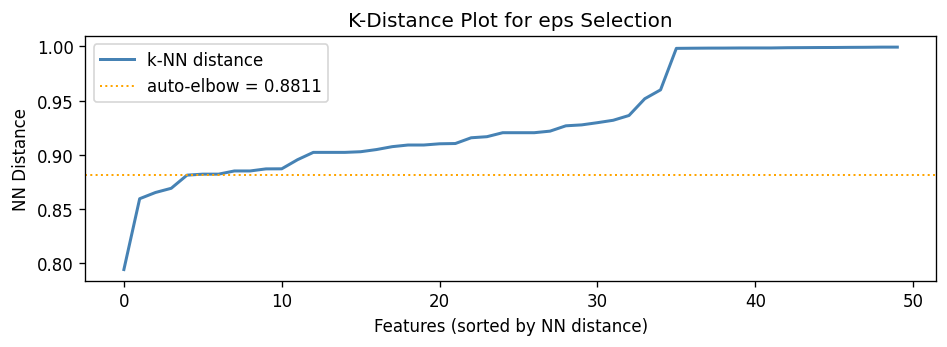

Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.831081769756263
Clusters found : 1
Noise features : 16  (32.0%)
eps decreased to  0.806081769756263
Clusters found : 2
Noise features : 18  (36.0%)

[Global MI]  median=0.0217  mean=0.0347 |G|=20  cmi_threshold=0.0058
  G = [3, 26, 16, 24, 27, 13, 23, 22, 10, 2, 12, 28, 18, 7, 1, 8, 21, 34, 9, 31]

[Cluster 0]  features=[0, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 24, 26, 27, 28, 31, 33, 34]
  context (G\cluster) = [23, 1]
    + feat=27  CMI=0.2585
    + feat=26  CMI=0.2897
    + feat=13  CMI=0.2504
    + feat=18  CMI=0.3677
    ~ weak feat=3  MI=0.1157
    ~ weak feat=16  MI=0.1061
    ~ weak feat=24  MI=0.1056
    ~ weak feat=22  MI=0.0827
    ~ weak feat=10  MI=0.0763
    ~ weak feat=2  MI=0.0630
    ~ weak feat=12  MI=0.0542
  → selected 11/27: [27, 26, 13, 18, 3, 16, 24, 22, 10, 2, 12]

[Cluster 1]  features=[5, 25, 29, 30, 32]
  context (G\cluster) = [3, 26, 16, 24, 27, 13, 23, 22, 10,

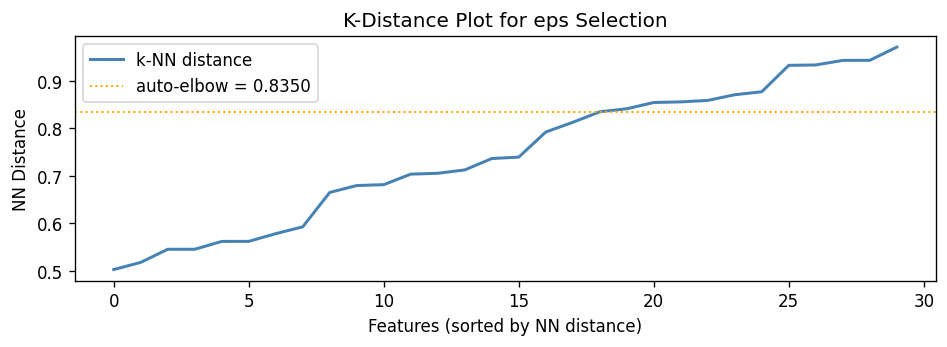

Clusters found : 1
Noise features : 5  (16.7%)
eps decreased to  0.7849508729328553
Clusters found : 1
Noise features : 7  (23.3%)
eps decreased to  0.7599508729328552
Clusters found : 1
Noise features : 7  (23.3%)
eps decreased to  0.7474508729328553
Clusters found : 1
Noise features : 7  (23.3%)
eps decreased to  0.7412008729328553
Clusters found : 1
Noise features : 9  (30.0%)
eps decreased to  0.7380758729328553
Clusters found : 1
Noise features : 9  (30.0%)
eps decreased to  0.7365133729328552
Clusters found : 1
Noise features : 9  (30.0%)
eps decreased to  0.7357321229328553
Clusters found : 1
Noise features : 9  (30.0%)
eps decreased to  0.7353414979328553
Clusters found : 1
Noise features : 9  (30.0%)
eps decreased to  0.7351461854328553
Clusters found : 1
Noise features : 9  (30.0%)
eps decreased to  0.7350485291828552
Clusters found : 1
Noise features : 9  (30.0%)
eps decreased to  0.7349997010578553
Clusters found : 1
Noise features : 9  (30.0%)
eps decreased to  0.734975286

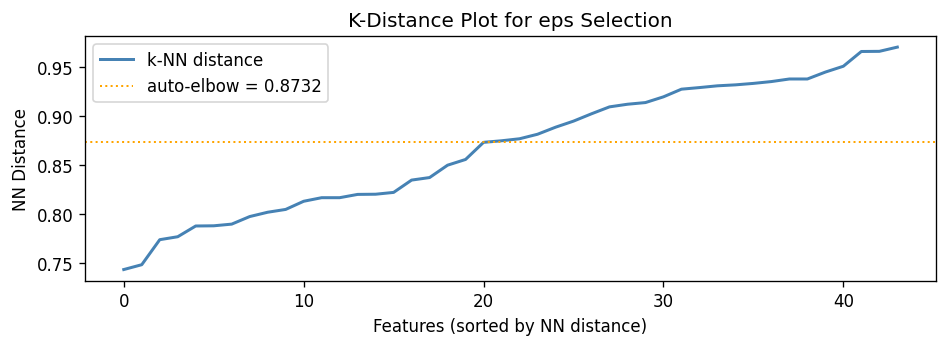

Clusters found : 1
Noise features : 4  (9.1%)
eps decreased to  0.8232430963858071
Clusters found : 2
Noise features : 12  (27.3%)

[Global MI]  median=0.0277  mean=0.0380 |G|=15  cmi_threshold=0.0050
  G = [25, 41, 39, 43, 24, 29, 5, 42, 40, 38, 14, 15, 13, 23, 21]

[Cluster 0]  features=[0, 1, 4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 17, 22, 23, 24, 25, 28, 29, 34, 35, 38, 39, 40, 41, 42, 43]
  context (G\cluster) = [21]
    + feat=41  CMI=0.1208
    + feat=4  CMI=0.1136
    + feat=8  CMI=0.1955
    + feat=17  CMI=0.3151
    + feat=42  CMI=0.3246
    + feat=39  CMI=0.3769
    + feat=28  CMI=0.4506
    ~ weak feat=25  MI=0.1007
    ~ weak feat=43  MI=0.0783
    ~ weak feat=24  MI=0.0782
    ~ weak feat=29  MI=0.0766
    ~ weak feat=5  MI=0.0697
    ~ weak feat=40  MI=0.0655
    ~ weak feat=38  MI=0.0570
  → selected 14/28: [41, 4, 8, 17, 42, 39, 28, 25, 43, 24, 29, 5, 40, 38]

[Cluster 1]  features=[30, 31, 32, 33]
  context (G\cluster) = [25, 41, 39, 43, 24, 29, 5, 42, 40, 38, 14, 15, 1

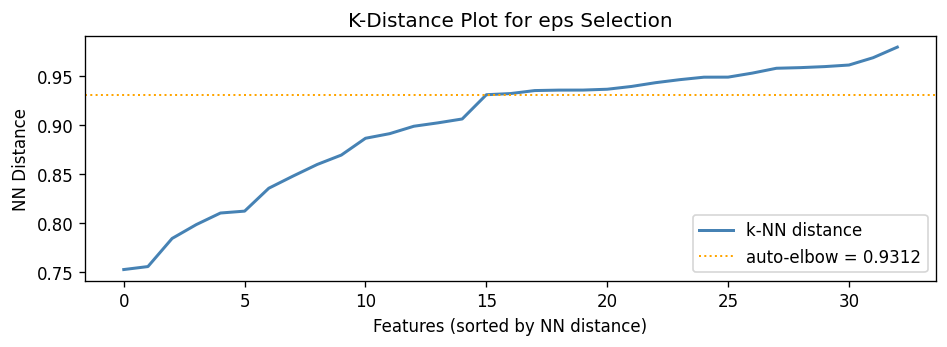

Clusters found : 1
Noise features : 2  (6.1%)
eps decreased to  0.8811778415557145
Clusters found : 3
Noise features : 7  (21.2%)

[Global MI]  median=0.0959  mean=0.1062 |G|=13  cmi_threshold=0.0118
  G = [3, 1, 2, 29, 5, 26, 19, 27, 0, 31, 4, 23, 13]

[Cluster 0]  features=[1, 3, 5, 6, 7, 8, 9, 10, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]
  context (G\cluster) = [2, 26, 0, 4]
    + feat=13  CMI=0.2894
    + feat=21  CMI=0.0681
    + feat=9  CMI=0.0736
    + feat=1  CMI=0.0521
    ~ weak feat=3  MI=0.2361
    ~ weak feat=29  MI=0.1677
    ~ weak feat=5  MI=0.1664
    ~ weak feat=19  MI=0.1418
    ~ weak feat=27  MI=0.1375
  → selected 9/19: [13, 21, 9, 1, 3, 29, 5, 19, 27]

[Cluster 1]  features=[16, 18, 20, 24]
  context (G\cluster) = [3, 1, 2, 29, 5, 26, 19, 27, 0, 31, 4, 23, 13]
  MB empty — fallback kept feat=16  MI=0.0992
    ~ weak feat=18  MI=0.0621
  → selected 2/4: [16, 18]

[Cluster 2]  features=[26, 30, 32]
  context (G\cluster) = [3, 1, 2, 29, 5, 19, 27, 0, 31, 4, 23, 1

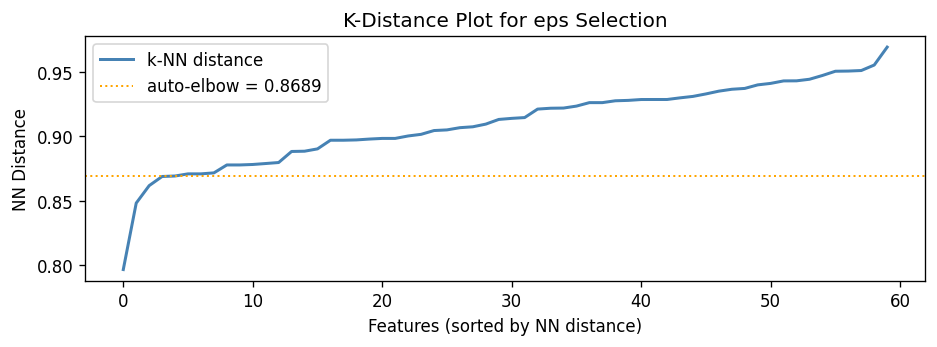

Clusters found : 3
Noise features : 2  (3.3%)

[Global MI]  median=0.0235  mean=0.0329 |G|=24  cmi_threshold=0.0063
  G = [11, 10, 8, 9, 48, 12, 47, 43, 35, 44, 20, 7, 34, 45, 5, 46, 42, 19, 0, 36, 26, 53, 31, 21]

[Cluster 0]  features=[0, 1, 2, 3, 4, 5]
  context (G\cluster) = [11, 10, 8, 9, 48, 12, 47, 43, 35, 44, 20, 7, 34, 45, 46, 42, 19, 36, 26, 53, 31, 21]
  MB empty — fallback kept feat=5  MI=0.0437
    ~ weak feat=0  MI=0.0392
    ~ weak feat=4  MI=0.0323
  → selected 3/6: [5, 0, 4]

[Cluster 1]  features=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
  context (G\cluster) = [5, 0, 53]
    + feat=11  CMI=0.3248
    + feat=10  CMI=0.3427
    + feat=21  CMI=0.2943
    ~ weak feat=8  MI=0.0963
    ~ weak feat=9  MI=0.0949
    ~ weak feat=48  MI=0.0786
    ~ weak feat=12  MI=0.0737
    ~ weak feat=47  MI=0.0657
    ~ weak feat=43  MI=0.0578
    ~ we

In [5]:
METHODS = ['Baseline', 'CluMarPareto', 'NSGA2 Standalone',
           'IAMB + NSGA2', 'IAMB Only', 'RF Importance', 'LASSO']

runners = {
    'Baseline':        lambda Xtr, Xte, ytr, yte, fc: run_baseline(Xtr, Xte, ytr, yte),
    'CluMarPareto':    run_clumarpareto,
    'NSGA2 Standalone': run_nsga2_standalone,
    'IAMB + NSGA2':    run_iamb_nsga2,
    'IAMB Only':       run_iamb_only,
    'RF Importance':   run_rf_importance,
    'LASSO':           run_lasso,
}

records = []
pareto_data = {}   # store pareto fronts for plot section 10

for ds_name, (X, y) in datasets.items():
    n_total = X.shape[1]
    feature_cols = [f'f{i}' for i in range(n_total)]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    print(f"\n{'='*60}\nDataset: {ds_name}  shape={X.shape}\n{'='*60}")

    for method_name, runner in runners.items():
        print(f"  Running {method_name}...", end=' ', flush=True)
        try:
            res = runner(X_train, X_test, y_train, y_test, feature_cols)
            # store pareto front if available
            if 'pareto_front' in res:
                pareto_data[(ds_name, method_name)] = res.pop('pareto_front')
            records.append({
                'dataset':       ds_name,
                'method':        method_name,
                'runtime':       res['runtime'],
                'n_selected':    res['n_selected'],
                'reduction_pct': res['reduction_pct'],
                'test_acc':      res['test_acc'],
                'n_total':       n_total,
                'selected_features': str(res.get('selected_features', []))
            })
            print(f"acc={res['test_acc']:.4f}  feats={res['n_selected']}  t={res['runtime']:.1f}s")
        except Exception as e:
            print(f"FAILED: {e}")
            records.append({
                'dataset': ds_name, 'method': method_name,
                'runtime': np.nan, 'n_selected': np.nan,
                'reduction_pct': np.nan, 'test_acc': np.nan,
                'n_total': n_total, 'selected_features': '[]'
            })

results_df = pd.DataFrame(records)
print("\nBenchmark complete.")


## 6. Performance Comparison Table

In [6]:
pivot_acc = results_df.pivot(index='dataset', columns='method', values='test_acc')[METHODS]
pivot_sel = results_df.pivot(index='dataset', columns='method', values='n_selected')[METHODS]
pivot_rt  = results_df.pivot(index='dataset', columns='method', values='runtime')[METHODS]

print("=== Test Accuracy ===")
display(pivot_acc.round(4).style.highlight_max(axis=1, color='lightgreen')
                                .highlight_min(axis=1, color='#ffcccc'))

print("\n=== Features Selected ===")
display(pivot_sel.style.highlight_min(axis=1, color='lightgreen'))

print("\n=== Runtime (seconds) ===")
display(pivot_rt.round(1).style.highlight_min(axis=1, color='lightgreen'))


=== Test Accuracy ===


method,Baseline,CluMarPareto,NSGA2 Standalone,IAMB + NSGA2,IAMB Only,RF Importance,LASSO
dataset,,,,,,,
BreastCancer,0.921100,0.938600,0.929800,0.929800,0.938600,0.938600,0.938600
Ionosphere,0.887300,0.957700,0.957700,0.971800,0.943700,0.929600,0.929600
SPECTF,0.740700,0.759300,0.703700,0.722200,0.759300,0.722200,0.759300
Sonar,0.833300,0.809500,0.809500,0.690500,0.833300,0.785700,0.714300
Synthetic,0.785000,0.835000,0.835000,0.835000,0.810000,0.835000,0.825000



=== Features Selected ===


method,Baseline,CluMarPareto,NSGA2 Standalone,IAMB + NSGA2,IAMB Only,RF Importance,LASSO
dataset,,,,,,,
BreastCancer,30,4,4,4,14,9,7
Ionosphere,33,5,5,3,15,8,9
SPECTF,44,9,5,3,19,17,9
Sonar,60,12,10,5,27,18,11
Synthetic,50,5,5,5,22,18,13



=== Runtime (seconds) ===


method,Baseline,CluMarPareto,NSGA2 Standalone,IAMB + NSGA2,IAMB Only,RF Importance,LASSO
dataset,,,,,,,
BreastCancer,0.000000,159.100000,105.000000,42.900000,0.300000,0.100000,0.000000
Ionosphere,0.000000,70.500000,151.400000,38.200000,0.100000,0.100000,0.000000
SPECTF,0.000000,89.400000,86.500000,82.100000,0.300000,0.100000,0.000000
Sonar,0.000000,104.500000,127.700000,92.900000,0.200000,0.100000,0.000000
Synthetic,0.000000,111.300000,108.200000,135.100000,1.000000,0.100000,0.000000


## 7. Accuracy vs Number of Features

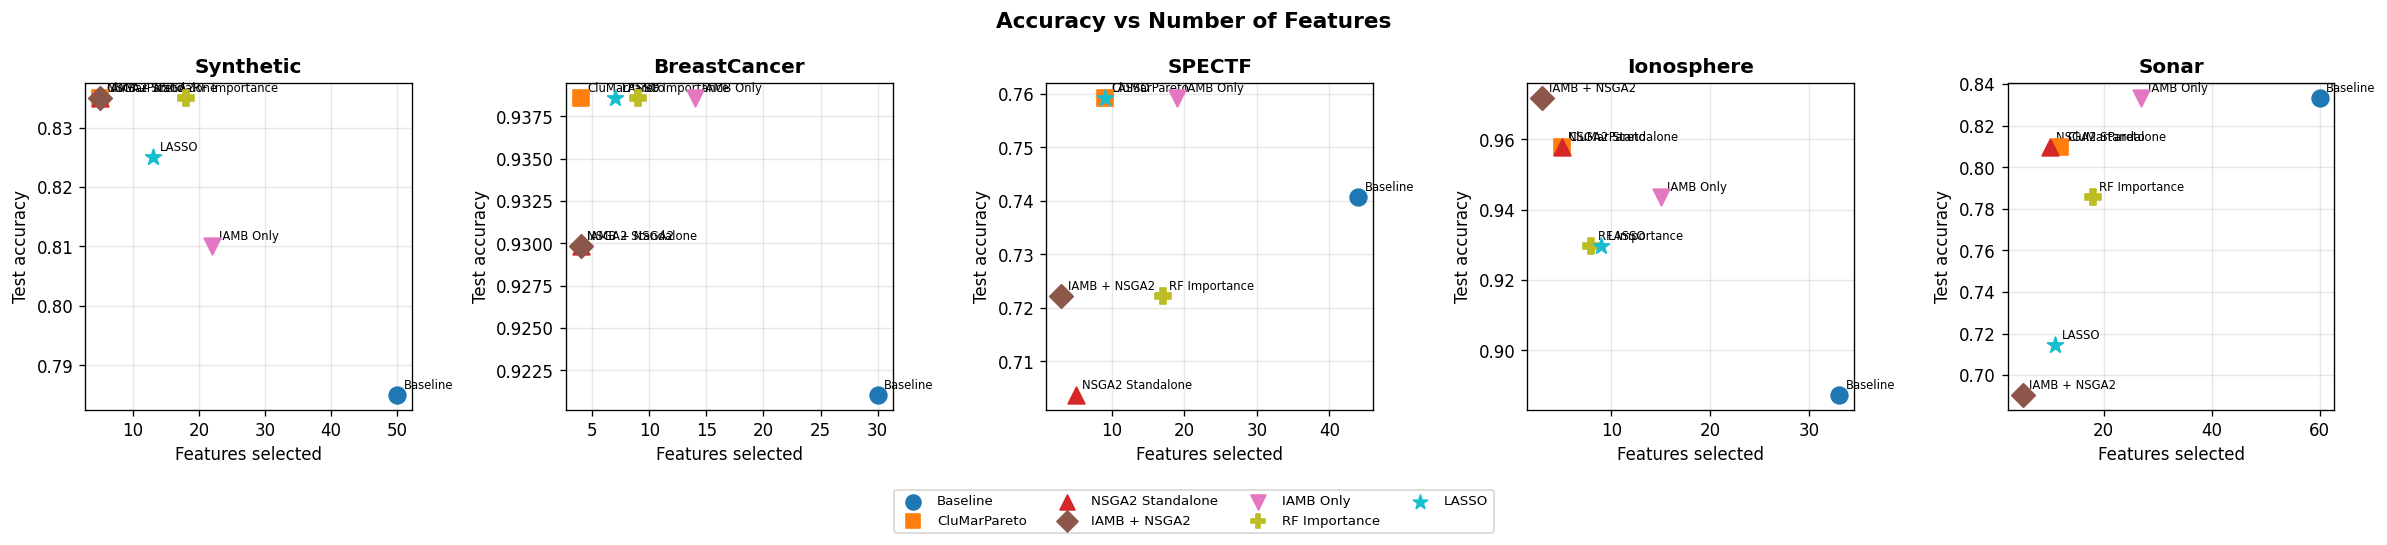

In [7]:
colors = plt.cm.tab10(np.linspace(0, 1, len(METHODS)))
color_map = dict(zip(METHODS, colors))
markers   = ['o','s','^','D','v','P','*']
marker_map = dict(zip(METHODS, markers))

ds_names = results_df['dataset'].unique()
n_ds = len(ds_names)
fig, axes = plt.subplots(1, n_ds, figsize=(4 * n_ds, 4), sharey=False)
if n_ds == 1:
    axes = [axes]

for ax, ds in zip(axes, ds_names):
    sub = results_df[results_df['dataset'] == ds]
    for i, method in enumerate(METHODS):
        row = sub[sub['method'] == method]
        if row.empty or row['n_selected'].isna().any():
            continue
        ax.scatter(row['n_selected'], row['test_acc'],
                   color=color_map[method], marker=marker_map[method],
                   s=100, zorder=5, label=method)
        ax.annotate(method, (row['n_selected'].values[0], row['test_acc'].values[0]),
                    textcoords='offset points', xytext=(4, 4), fontsize=7)
    ax.set_title(ds, fontweight='bold')
    ax.set_xlabel('Features selected')
    ax.set_ylabel('Test accuracy')
    ax.grid(alpha=0.3)

handles = [plt.scatter([],[], color=color_map[m], marker=marker_map[m], s=80, label=m)
           for m in METHODS]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.12), fontsize=8)
plt.suptitle('Accuracy vs Number of Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Runtime Comparison

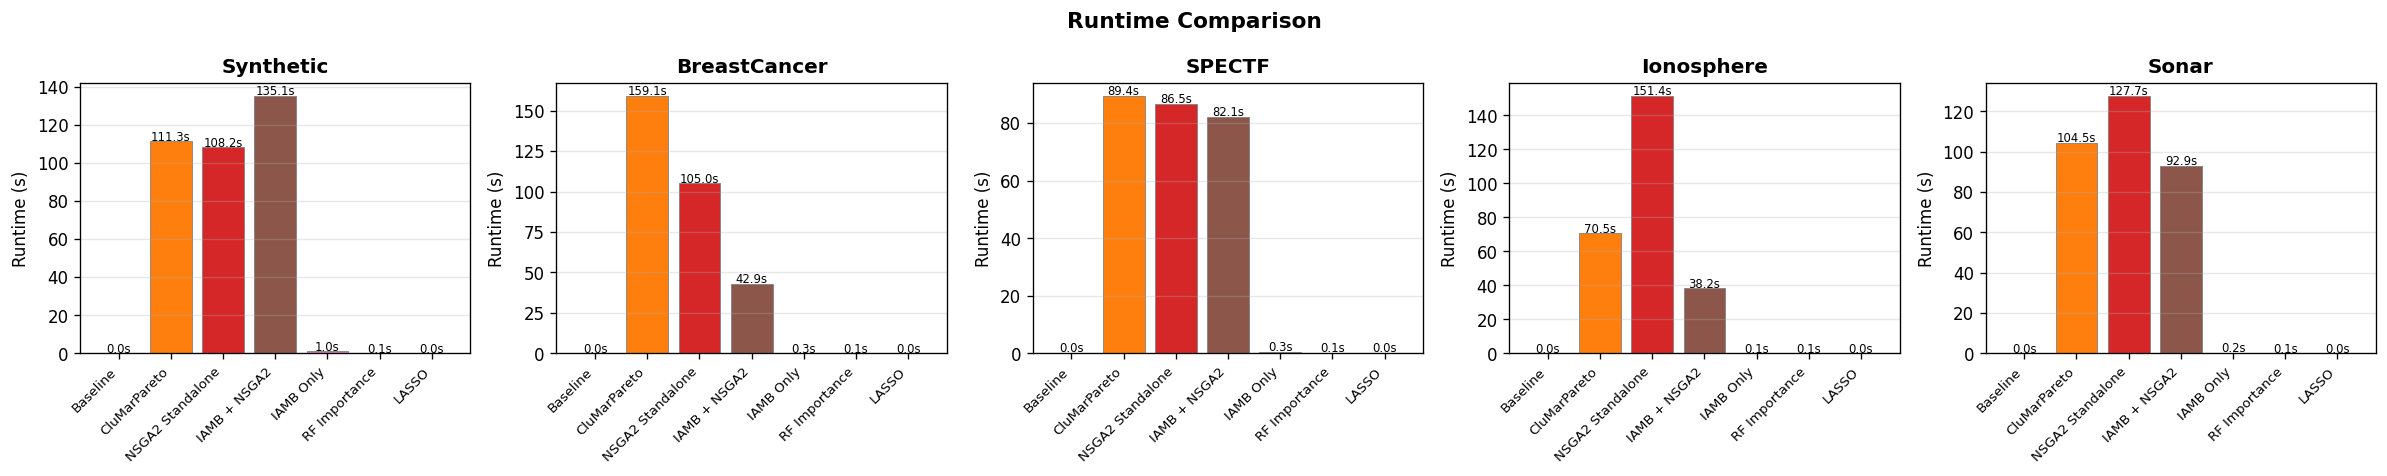

In [8]:
fig, axes = plt.subplots(1, n_ds, figsize=(4 * n_ds, 4))
if n_ds == 1:
    axes = [axes]

for ax, ds in zip(axes, ds_names):
    sub     = results_df[results_df['dataset'] == ds]
    methods = [m for m in METHODS if not sub[sub['method']==m]['runtime'].isna().all()]
    rts     = [sub[sub['method']==m]['runtime'].values[0] for m in methods]
    bars    = ax.bar(range(len(methods)), rts,
                     color=[color_map[m] for m in methods], edgecolor='grey', linewidth=0.5)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Runtime (s)')
    ax.set_title(ds, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, rts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}s', ha='center', fontsize=7)

plt.suptitle('Runtime Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Feature Reduction Analysis

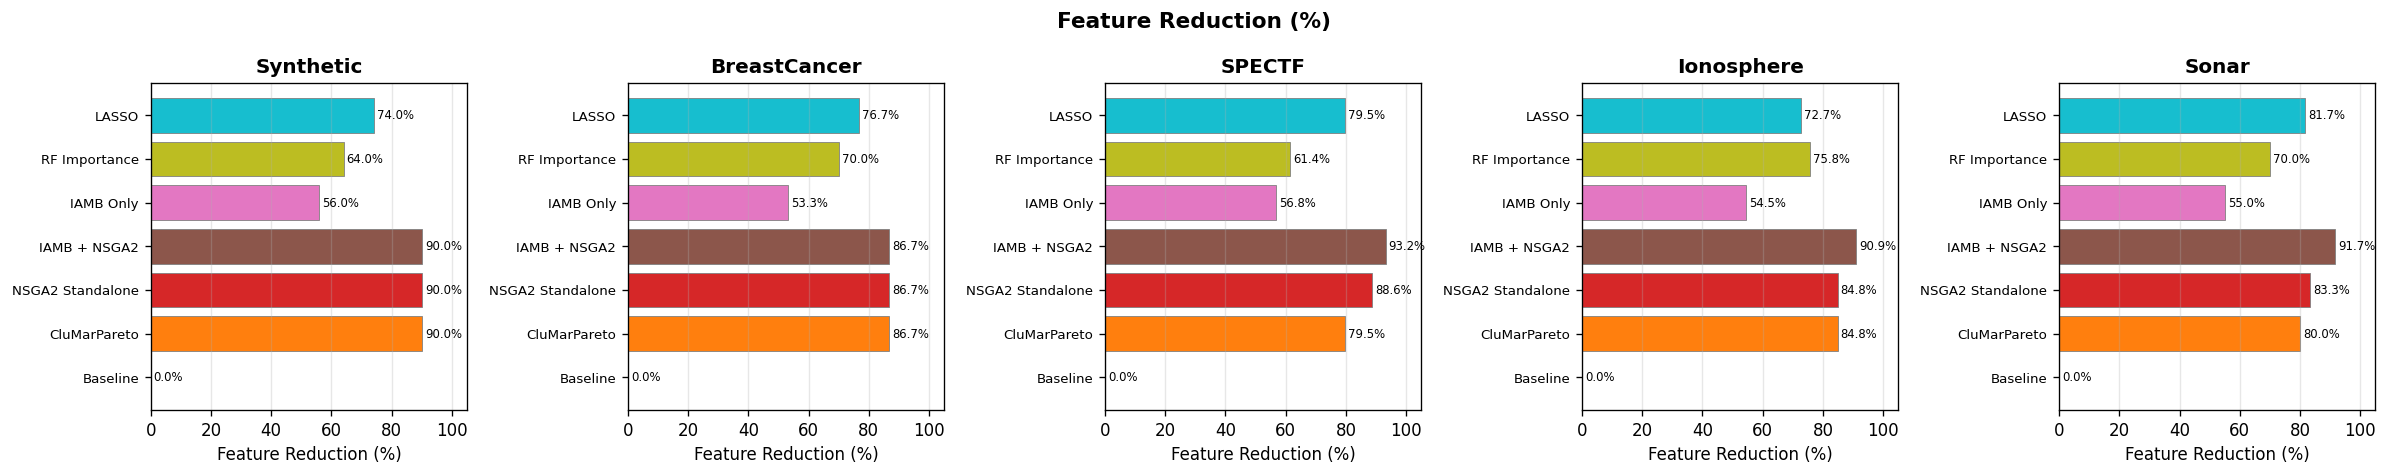

In [9]:
fig, axes = plt.subplots(1, n_ds, figsize=(4 * n_ds, 4))
if n_ds == 1:
    axes = [axes]

for ax, ds in zip(axes, ds_names):
    sub     = results_df[results_df['dataset'] == ds]
    methods = [m for m in METHODS if not sub[sub['method']==m]['reduction_pct'].isna().all()]
    reds    = [sub[sub['method']==m]['reduction_pct'].values[0] for m in methods]
    ax.barh(range(len(methods)), reds,
            color=[color_map[m] for m in methods], edgecolor='grey', linewidth=0.5)
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels(methods, fontsize=8)
    ax.set_xlabel('Feature Reduction (%)')
    ax.set_title(ds, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.grid(axis='x', alpha=0.3)
    for i, val in enumerate(reds):
        ax.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=7)

plt.suptitle('Feature Reduction (%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Stability Analysis (Multiple Runs)

Each method is run `N_STABILITY_RUNS` times with different train/test splits.
Measures mean and std of accuracy across runs.

eps calculated through elbow curve:  0.8720548492109002


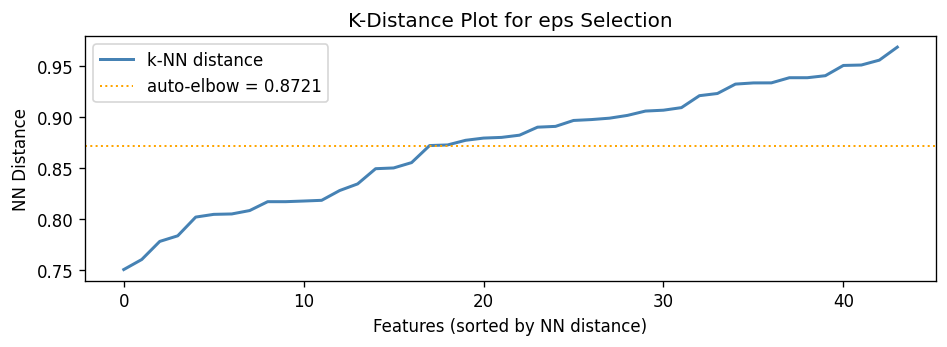

Clusters found : 2
Noise features : 2  (4.5%)

[Global MI]  median=0.0348  mean=0.0364 |G|=21  cmi_threshold=0.0037
  G = [41, 25, 39, 42, 43, 5, 29, 38, 40, 24, 13, 14, 15, 3, 23, 19, 21, 1, 28, 27, 35]

[Cluster 0]  features=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 22, 23, 24, 25, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]
  context (G\cluster) = [19, 21, 27]
    + feat=3  CMI=0.2265
    + feat=8  CMI=0.3639
    + feat=24  CMI=0.4064
    + feat=17  CMI=0.6159
    ~ weak feat=41  MI=0.0744
    ~ weak feat=25  MI=0.0737
    ~ weak feat=39  MI=0.0725
    ~ weak feat=42  MI=0.0665
    ~ weak feat=43  MI=0.0645
    ~ weak feat=5  MI=0.0636
    ~ weak feat=29  MI=0.0635
    ~ weak feat=38  MI=0.0570
    ~ weak feat=40  MI=0.0556
    ~ weak feat=13  MI=0.0492
    ~ weak feat=14  MI=0.0470
  → selected 15/38: [3, 8, 24, 17, 41, 25, 39, 42, 43, 5, 29, 38, 40, 13, 14]

[Cluster 1]  features=[18, 19, 20, 21]
  context (G\cluster) = [41, 25, 39, 42, 43,

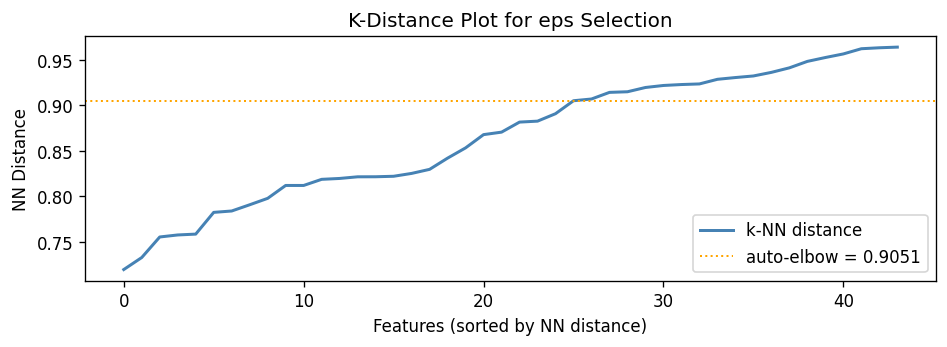

Clusters found : 1
Noise features : 0  (0.0%)
eps decreased to  0.855129177961645
Clusters found : 1
Noise features : 8  (18.2%)
eps decreased to  0.830129177961645
Clusters found : 2
Noise features : 8  (18.2%)

[Global MI]  median=0.0255  mean=0.0350 |G|=17  cmi_threshold=0.0051
  G = [25, 39, 29, 5, 42, 41, 43, 40, 24, 13, 14, 7, 15, 38, 4, 28, 3]

[Cluster 0]  features=[0, 1, 4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 17, 22, 23, 24, 25, 28, 29, 34, 35, 38, 39, 40, 41, 42, 43]
  context (G\cluster) = [3]
    + feat=25  CMI=0.1074
    + feat=9  CMI=0.1307
    + feat=15  CMI=0.2444
    + feat=12  CMI=0.3703
    + feat=7  CMI=0.3120
    ~ weak feat=39  MI=0.0834
    ~ weak feat=29  MI=0.0748
    ~ weak feat=5  MI=0.0745
    ~ weak feat=42  MI=0.0708
    ~ weak feat=41  MI=0.0706
    ~ weak feat=43  MI=0.0681
    ~ weak feat=40  MI=0.0638
  → selected 12/28: [25, 9, 15, 12, 7, 39, 29, 5, 42, 41, 43, 40]

[Cluster 1]  features=[2, 3, 10, 11, 30, 31, 32, 33]
  context (G\cluster) = [25, 39, 2

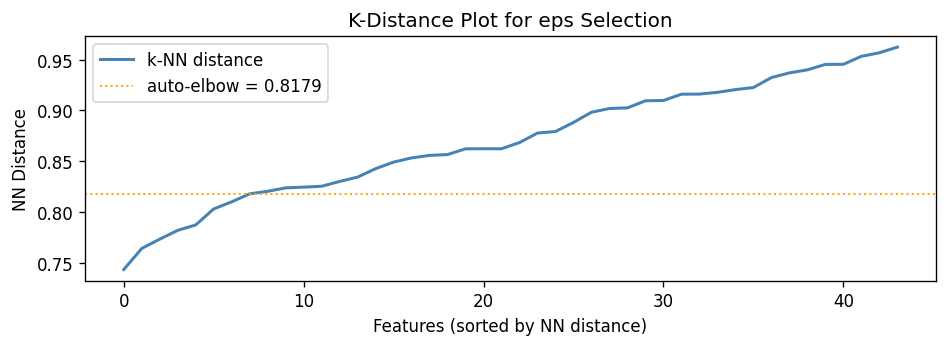

Clusters found : 2
Noise features : 8  (18.2%)

[Global MI]  median=0.0258  mean=0.0367 |G|=18  cmi_threshold=0.0055
  G = [25, 5, 39, 41, 40, 24, 14, 29, 43, 42, 13, 23, 15, 38, 28, 31, 3, 27]

[Cluster 0]  features=[0, 1, 4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 17, 22, 23, 24, 25, 28, 29, 34, 35, 38, 39, 40, 41, 42, 43]
  context (G\cluster) = [31, 3, 27]
    + feat=42  CMI=0.1788
    + feat=43  CMI=0.2810
    + feat=22  CMI=0.4097
    + feat=7  CMI=0.5579
    ~ weak feat=25  MI=0.1091
    ~ weak feat=5  MI=0.0947
    ~ weak feat=39  MI=0.0815
    ~ weak feat=41  MI=0.0795
    ~ weak feat=40  MI=0.0676
    ~ weak feat=24  MI=0.0674
    ~ weak feat=14  MI=0.0644
    ~ weak feat=29  MI=0.0597
  → selected 12/28: [42, 43, 22, 7, 25, 5, 39, 41, 40, 24, 14, 29]

[Cluster 1]  features=[2, 3, 10, 11, 30, 31, 32, 33]
  context (G\cluster) = [25, 5, 39, 41, 40, 24, 14, 29, 43, 42, 13, 23, 15, 38, 28, 27]
  MB empty — fallback kept feat=31  MI=0.0433
    ~ weak feat=3  MI=0.0403
    ~ weak feat=

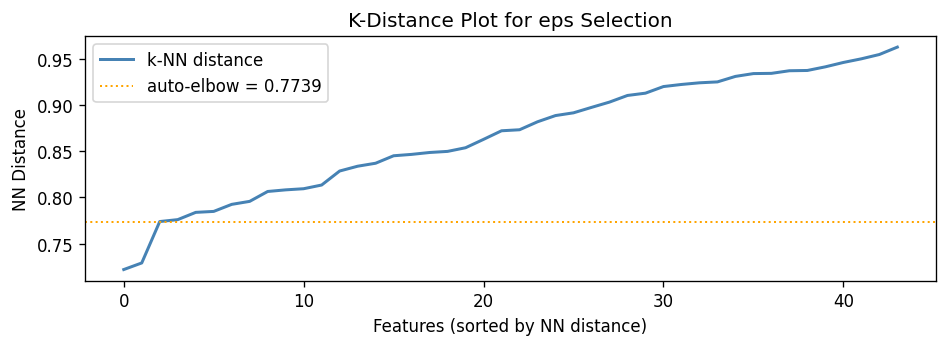

Clusters found : 3
Noise features : 16  (36.4%)

[Global MI]  median=0.0277  mean=0.0370 |G|=18  cmi_threshold=0.0051
  G = [25, 5, 41, 39, 43, 29, 42, 40, 24, 14, 31, 13, 15, 38, 23, 21, 4, 28]

[Cluster 0]  features=[4, 5, 14, 15, 24, 25, 40, 41, 42, 43]
  context (G\cluster) = [39, 29, 31, 13, 38, 23, 21, 28]
  MB empty — fallback kept feat=25  MI=0.1021
    ~ weak feat=5  MI=0.0805
    ~ weak feat=41  MI=0.0763
    ~ weak feat=43  MI=0.0726
  → selected 4/10: [25, 5, 41, 43]

[Cluster 1]  features=[6, 7, 16, 17, 28, 29, 34, 35, 38, 39]
  context (G\cluster) = [25, 5, 41, 43, 42, 40, 24, 14, 31, 13, 15, 23, 21, 4]
  MB empty — fallback kept feat=39  MI=0.0738
    ~ weak feat=29  MI=0.0676
    ~ weak feat=38  MI=0.0516
    ~ weak feat=28  MI=0.0376
  → selected 4/10: [39, 29, 38, 28]

[Cluster 2]  features=[12, 13, 22, 23, 30, 31, 32, 33]
  context (G\cluster) = [25, 5, 41, 39, 43, 29, 42, 40, 24, 14, 15, 38, 21, 4, 28]
  MB empty — fallback kept feat=31  MI=0.0609
    ~ weak feat=13

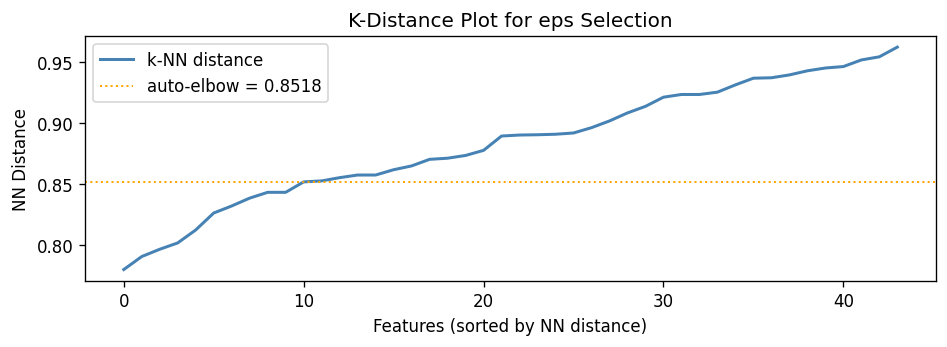

Clusters found : 2
Noise features : 3  (6.8%)

[Global MI]  median=0.0259  mean=0.0340 |G|=16  cmi_threshold=0.0050
  G = [39, 43, 42, 41, 25, 29, 3, 13, 40, 5, 31, 38, 28, 24, 23, 14]

[Cluster 0]  features=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 38, 39, 40, 41, 42, 43]
  context (G\cluster) = []
    + feat=39  CMI=0.0992
    + feat=32  CMI=0.0675
    + feat=16  CMI=0.0929
    + feat=9  CMI=0.1292
    + feat=35  CMI=0.1869
    + feat=8  CMI=0.3042
    + feat=14  CMI=0.3475
    + feat=38  CMI=0.6024
    ~ weak feat=43  MI=0.0884
    ~ weak feat=42  MI=0.0799
    ~ weak feat=41  MI=0.0672
    ~ weak feat=25  MI=0.0667
    ~ weak feat=29  MI=0.0616
    ~ weak feat=3  MI=0.0561
    ~ weak feat=13  MI=0.0556
    ~ weak feat=40  MI=0.0530
    ~ weak feat=5  MI=0.0524
  → selected 17/37: [39, 32, 16, 9, 35, 8, 14, 38, 43, 42, 41, 25, 29, 3, 13, 40, 5]

[Cluster 1]  features=[18, 19, 20, 21]
  context (G\cluster) = [3

,Mean Accuracy,Std Accuracy,Mean Features,Std Features,Runs
Method,,,,,
CluMarPareto,0.722200,0.038800,5.800000,1.469700,5
NSGA2 Standalone,0.737000,0.052900,7.600000,2.154100,5
IAMB + NSGA2,0.748100,0.059300,6.400000,1.743600,5
IAMB Only,0.722200,0.026200,21.400000,1.854700,5
RF Importance,0.733300,0.044800,17.400000,1.496700,5
LASSO,0.733300,0.039900,7.200000,1.720500,5


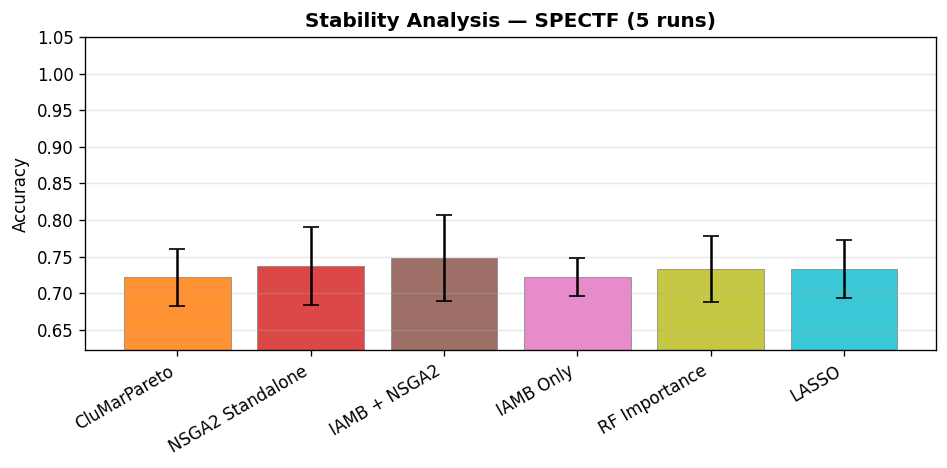

In [10]:
STABILITY_DATASET = 'SPECTF'   # change as needed

X_s, y_s = datasets[STABILITY_DATASET]
fc_s     = [f'f{i}' for i in range(X_s.shape[1])]
seeds    = list(range(N_STABILITY_RUNS))

stability_methods = {
    'CluMarPareto':    run_clumarpareto,
    'NSGA2 Standalone': run_nsga2_standalone,
    'IAMB + NSGA2':    run_iamb_nsga2,
    'IAMB Only':       run_iamb_only,
    'RF Importance':   run_rf_importance,
    'LASSO':           run_lasso,
}

stab_records = []
for method_name, runner in stability_methods.items():
    accs, feats = [], []
    for seed in seeds:
        Xtr, Xte, ytr, yte = train_test_split(
            X_s, y_s, test_size=0.2, random_state=seed, stratify=y_s)
        try:
            res = runner(Xtr, Xte, ytr, yte, fc_s)
            accs.append(res['test_acc'])
            feats.append(res['n_selected'])
        except Exception:
            pass
    if accs:
        stab_records.append({
            'Method':       method_name,
            'Mean Accuracy': np.mean(accs),
            'Std Accuracy':  np.std(accs),
            'Mean Features': np.mean(feats),
            'Std Features':  np.std(feats),
            'Runs':          len(accs)
        })
        print(f"  {method_name}: acc={np.mean(accs):.4f} ± {np.std(accs):.4f}  "
              f"feats={np.mean(feats):.1f} ± {np.std(feats):.1f}")

stab_df = pd.DataFrame(stab_records).set_index('Method')
display(stab_df.round(4).style
        .highlight_min(subset=['Std Accuracy'], color='lightgreen')
        .highlight_max(subset=['Mean Accuracy'], color='lightblue'))

# Error bar plot
fig, ax = plt.subplots(figsize=(8, 4))
methods_s = stab_df.index.tolist()
x = np.arange(len(methods_s))
ax.bar(x, stab_df['Mean Accuracy'],
       yerr=stab_df['Std Accuracy'], capsize=5,
       color=[color_map.get(m, 'grey') for m in methods_s],
       edgecolor='grey', linewidth=0.5, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(methods_s, rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title(f'Stability Analysis — {STABILITY_DATASET} ({N_STABILITY_RUNS} runs)',
             fontweight='bold')
ax.set_ylim(max(0, stab_df['Mean Accuracy'].min() - 0.1), 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Synthetic Dataset — Ground Truth Evaluation

For the Synthetic dataset, true informative features are indices 0–9 (first 10).
Computes Precision and Recall for each method.

In [ ]:
TRUE_INFORMATIVE = set(range(10))   # first 10 features are informative

syn_rows = results_df[results_df['dataset'] == 'Synthetic'].copy()

gt_records = []
for _, row in syn_rows.iterrows():
    try:
        sel_str = row['selected_features']
        # parse feature names like 'f0', 'f1', ...
        selected_set = set(int(s.strip().strip("'f")) for s in
                           sel_str.strip("[]").split(',') if s.strip())
    except Exception:
        selected_set = set()

    if len(selected_set) == 0:
        precision, recall, f1 = 0.0, 0.0, 0.0
    else:
        tp        = len(selected_set & TRUE_INFORMATIVE)
        precision = tp / len(selected_set)
        recall    = tp / len(TRUE_INFORMATIVE)
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0.0)
    gt_records.append({
        'Method':    row['method'],
        'Precision': precision,
        'Recall':    recall,
        'F1':        f1,
        'Selected':  len(selected_set)
    })

gt_df = pd.DataFrame(gt_records).set_index('Method')
print("Ground Truth Evaluation — Synthetic Dataset (informative features: 0–9)")
display(gt_df.round(4).style
        .highlight_max(subset=['Precision','Recall','F1'], color='lightgreen'))

# Precision-Recall bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x     = np.arange(len(gt_df))
width = 0.3
ax.bar(x - width/2, gt_df['Precision'], width, label='Precision',
       color='steelblue', alpha=0.85, edgecolor='grey')
ax.bar(x + width/2, gt_df['Recall'],   width, label='Recall',
       color='coral', alpha=0.85, edgecolor='grey')
ax.set_xticks(x)
ax.set_xticklabels(gt_df.index, rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Precision & Recall on Informative Features — Synthetic', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Pareto Front Analysis

Visualises the Pareto front produced by NSGA-II based methods.
Knee point (GRA-selected solution) is marked.

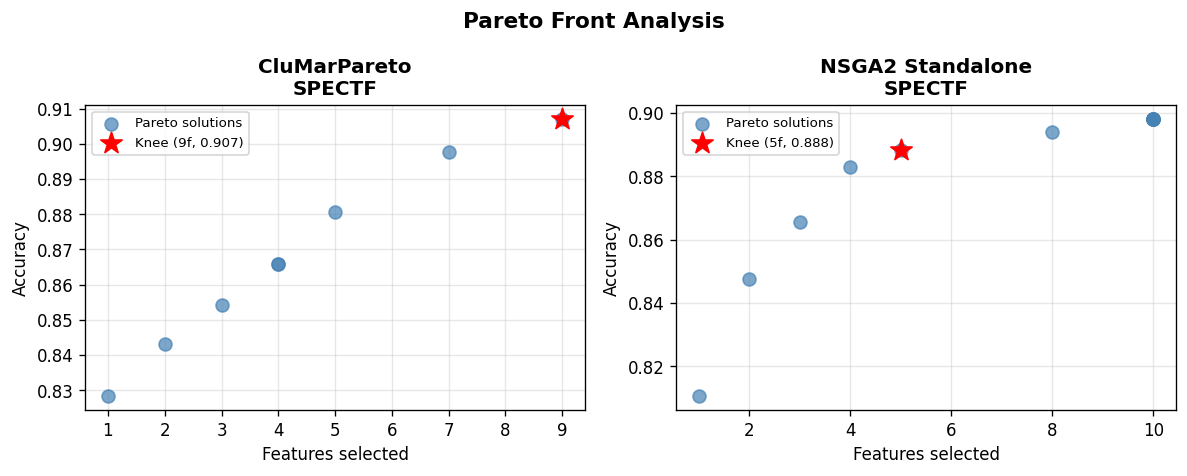

In [14]:
PARETO_DATASET = 'SPECTF'   # change as needed

pareto_methods = [k for k in pareto_data if k[0] == PARETO_DATASET]
if not pareto_methods:
    print("No Pareto data available for", PARETO_DATASET,
          "— run section 5 first.")
else:
    fig, axes = plt.subplots(1, len(pareto_methods),
                             figsize=(5 * len(pareto_methods), 4), squeeze=False)
    for ax, (ds, method) in zip(axes[0], pareto_methods):
        front   = pareto_data[(ds, method)]
        feats   = [ind.obj_scores[0] for ind in front]
        accs    = [ind.obj_scores[1] for ind in front]

        # find knee using NSGA2 method
        try:
            nsga_tmp = NSGA2_FS.__new__(NSGA2_FS)
            knee     = nsga_tmp.find_knee_point(front)
            kf, ka   = knee.obj_scores[0], knee.obj_scores[1]
        except Exception:
            kf, ka = None, None

        ax.scatter(feats, accs, s=60, color='steelblue',
                   alpha=0.7, label='Pareto solutions', zorder=4)
        if kf is not None:
            ax.scatter([kf], [ka], s=180, color='red', marker='*',
                       zorder=6, label=f'Knee ({kf}f, {ka:.3f})')
        ax.set_xlabel('Features selected')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{method}\n{ds}', fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle('Pareto Front Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 14. Accuracy vs Runtime Trade-off

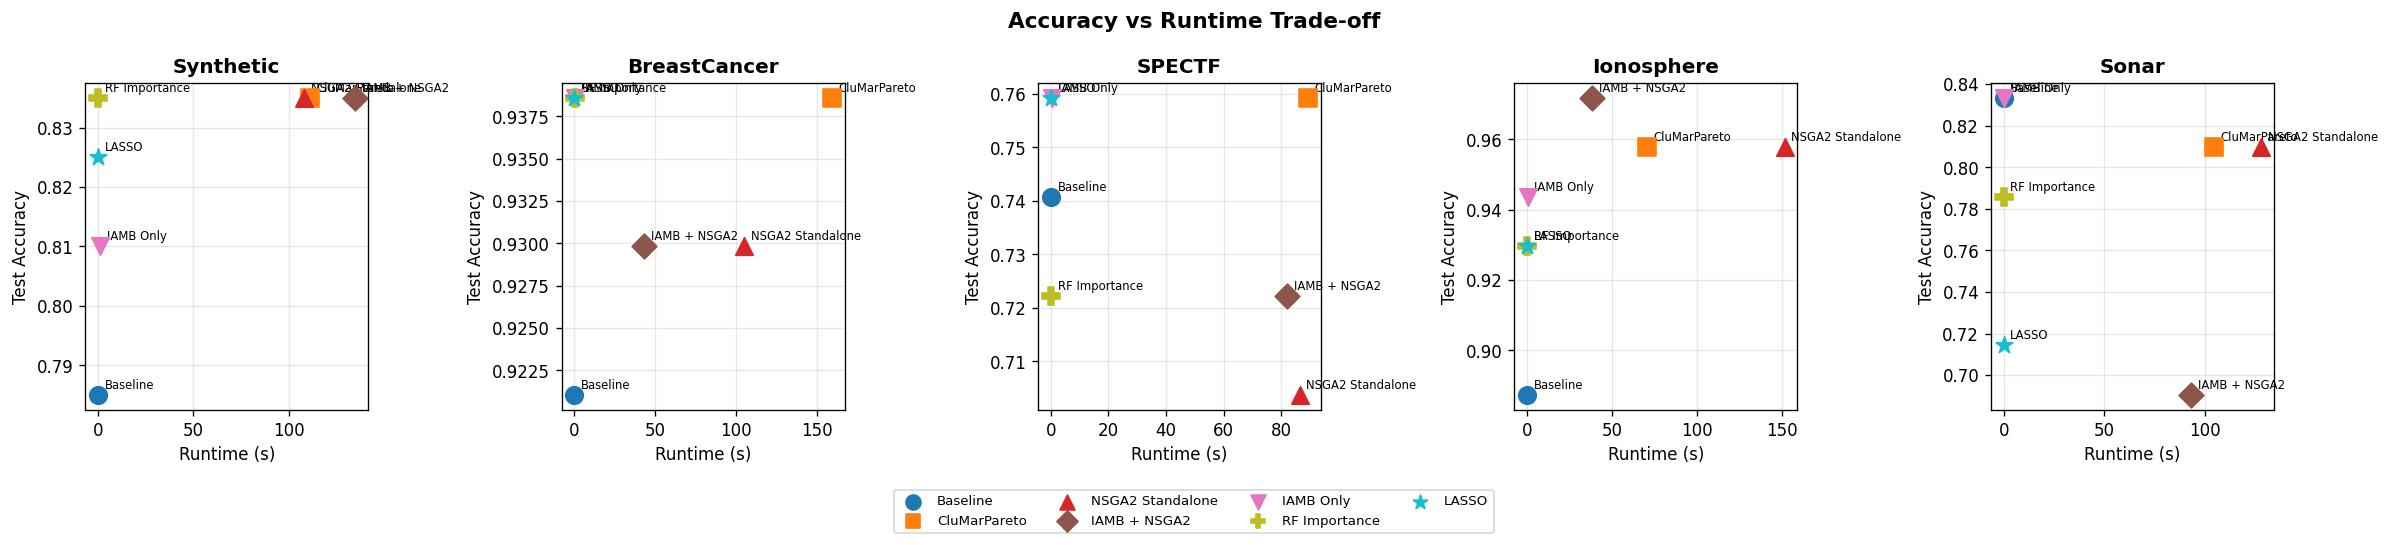

In [15]:
fig, axes = plt.subplots(1, n_ds, figsize=(4 * n_ds, 4))
if n_ds == 1:
    axes = [axes]

for ax, ds in zip(axes, ds_names):
    sub = results_df[results_df['dataset'] == ds]
    for i, method in enumerate(METHODS):
        row = sub[sub['method'] == method]
        if row.empty or row['runtime'].isna().any():
            continue
        ax.scatter(row['runtime'], row['test_acc'],
                   color=color_map[method], marker=marker_map[method],
                   s=110, zorder=5, label=method)
        ax.annotate(method,
                    (row['runtime'].values[0], row['test_acc'].values[0]),
                    textcoords='offset points', xytext=(4, 4), fontsize=7)
    ax.set_title(ds, fontweight='bold')
    ax.set_xlabel('Runtime (s)')
    ax.set_ylabel('Test Accuracy')
    ax.grid(alpha=0.3)

handles = [plt.scatter([],[], color=color_map[m], marker=marker_map[m], s=80, label=m)
           for m in METHODS]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.12), fontsize=8)
plt.suptitle('Accuracy vs Runtime Trade-off', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 15. Summary Statistics — Average Rank

In [13]:
rank_acc  = results_df.pivot(index='dataset', columns='method',
                               values='test_acc')[METHODS]
rank_rt   = results_df.pivot(index='dataset', columns='method',
                               values='runtime')[METHODS]
rank_nsel = results_df.pivot(index='dataset', columns='method',
                               values='n_selected')[METHODS]

avg_rank_acc  = rank_acc.rank(axis=1,  ascending=False).mean()
avg_rank_rt   = rank_rt.rank(axis=1,   ascending=True).mean()
avg_rank_nsel = rank_nsel.rank(axis=1, ascending=True).mean()

summary = pd.DataFrame({
    'Avg Rank (Accuracy↑)':  avg_rank_acc,
    'Avg Rank (Runtime↓)':   avg_rank_rt,
    'Avg Rank (Features↓)':  avg_rank_nsel,
})
summary['Overall Avg Rank'] = summary.mean(axis=1)
summary = summary.sort_values('Overall Avg Rank')

print("Average Rank across all datasets (lower = better)")
display(summary.style.format('{:.2f}').highlight_min(color='lightgreen'))


Average Rank across all datasets (lower = better)


,Avg Rank (Accuracy↑),Avg Rank (Runtime↓),Avg Rank (Features↓),Overall Avg Rank
method,,,,
LASSO,4.20,1.00,3.90,3.03
IAMB + NSGA2,4.30,5.40,1.40,3.70
CluMarPareto,2.60,6.40,2.80,3.93
RF Importance,4.20,3.00,4.80,4.00
NSGA2 Standalone,4.20,6.20,2.10,4.17
IAMB Only,3.20,4.00,6.00,4.40
Baseline,5.30,2.00,7.00,4.77


## 16. Save Results

In [ ]:
import os
os.makedirs('Results_csv', exist_ok=True)
os.makedirs('Results_Images', exist_ok=True)

results_df.to_csv('Results_csv/benchmark_results.csv', index=False)
summary.to_csv('Results_csv/benchmark_summary.csv')
if 'stab_df' in dir():
    stab_df.to_csv('Results_csv/stability_results.csv')
if 'gt_df' in dir():
    gt_df.to_csv('Results_csv/groundtruth_synthetic.csv')

print("Saved:")
print("  Results_csv/benchmark_results.csv")
print("  Results_csv/benchmark_summary.csv")
print("  Results_csv/stability_results.csv")
print("  Results_csv/groundtruth_synthetic.csv")
